In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp 
from sklearn.linear_model import *

### Loading Data

In [124]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

In [125]:
station = df_bike_counts["station"]
bike_count = df_bike_counts["bike_count"]
datetime = pd.to_datetime(df_bike_counts["datetime"])

year, month, day, hour, day_name = datetime.dt.year, datetime.dt.month, datetime.dt.day, datetime.dt.hour, datetime.dt.day_name

### Spliting Data - Langebro Station

In [126]:
Station = "Langebro"

df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_holidays["datetime"] = pd.to_datetime(df_holidays["date"])
df_holidays["holiday"] = True

# merge bike counts with weather on full datetime
df_merged = pd.merge(df_bike_counts, df_weather, on="datetime", how="left")

# merge with holidays on date only
df_merged["date"] = df_merged["datetime"].dt.date
df_holidays["date"] = df_holidays["datetime"].dt.date

df_merged = pd.merge(df_merged, df_holidays[["date", "holiday"]], on="date", how="left")
df_merged["holiday"] = df_merged["holiday"].fillna(False)

df_merged.ffill(inplace=True)

df_training = df_merged[(df_merged["datetime"].dt.year == 2021) & (df_merged["station"] == Station)].copy()
df_validating = df_merged[(df_merged["datetime"].dt.year == 2022) & (df_merged["station"] == Station)].copy()
df_testing = df_merged[(df_merged["datetime"].dt.year == 2023) & (df_merged["station"] == Station)].copy()

C:\Users\suzan\AppData\Local\Temp\ipykernel_17136\2602881298.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["holiday"] = df_merged["holiday"].fillna(False)


### Baseline Model - Predicting bike count from hour only

In [127]:
X = np.array(df_training['datetime'].dt.hour).reshape(-1, 1) #input
y = np.array(df_training["bike_count"]).reshape(-1, 1) #target

regr = LinearRegression()
regr.fit(X, y)

R2 = regr.score(X, y)
m = regr.coef_
c = regr.intercept_

def predict_count(h):
    pred = m*h + c
    return pred.flatten()

R2

0.010135418606116553

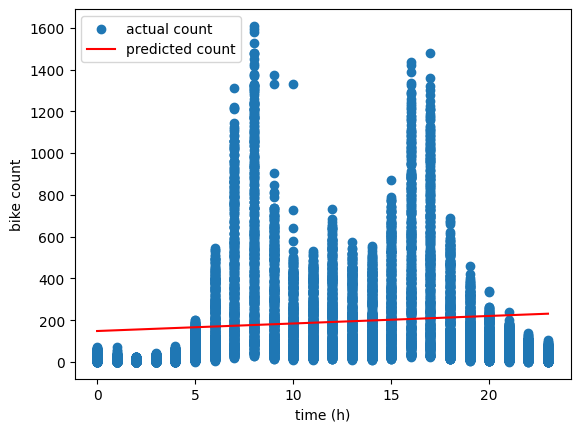

In [128]:
time_eval = np.arange(0, 24, 1)

plt.scatter(df_training["datetime"].dt.hour, df_training["bike_count"], label="actual count")
plt.plot(time_eval, predict_count(time_eval), label="predicted count", color = "red")
plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()

### Improved Model - Predicting bike count from cyclical hour

In [129]:
df_training["h_sin"] = np.sin(2 * np.pi * df_training["datetime"].dt.hour/ 24)
df_training["h_cos"] = np.cos(2 * np.pi * df_training["datetime"].dt.hour/ 24)

X = np.column_stack([df_training["h_sin"], df_training["h_cos"]]) #input
y = np.array(df_training["bike_count"]).reshape(-1, 1) #target

regr = LinearRegression()
regr.fit(X, y)

R2 = regr.score(X, y)

def predict_count_2(h):
    sin_h = np.sin(2 * np.pi * h / 24)
    cos_h = np.cos(2 * np.pi * h / 24)
    X_pred = np.column_stack([sin_h, cos_h])
    return regr.predict(X_pred).flatten()

R2

0.2119859445083555

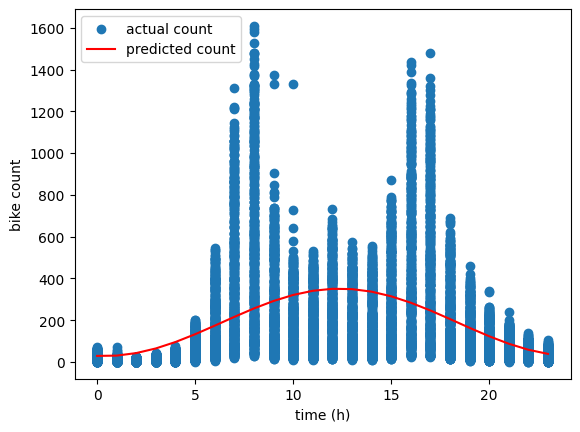

In [130]:
time_eval = np.arange(0, 24, 1)

plt.scatter(df_training["datetime"].dt.hour, df_training["bike_count"], label="actual count")
plt.plot(time_eval, predict_count_2(time_eval), label="predicted count", color = "red")
plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()

### Accounting for 2 peaks per day, weekend, public holiday, temp

In [131]:
df_training["is_weekend"] = df_training["datetime"].dt.dayofweek >= 5
df_training["is_holiday"] = df_training["holiday"] == True

df_training["temp1"] = df_training["temperature_C"]
df_training["temp2"] = df_training["temperature_C"] ** 2

df_training["h_sin1"] = np.sin(2 * np.pi * df_training["datetime"].dt.hour / 24)
df_training["h_cos1"] = np.cos(2 * np.pi * df_training["datetime"].dt.hour / 24)

df_training["h_sin2"] = np.sin(2 * np.pi * df_training["datetime"].dt.hour / 12)
df_training["h_cos2"] = np.cos(2 * np.pi * df_training["datetime"].dt.hour / 12)

X = np.column_stack([df_training["h_sin1"], 
                     df_training["h_cos1"], 
                     df_training["h_sin2"], 
                     df_training["h_cos2"], 
                     df_training["is_weekend"], 
                     df_training["is_holiday"], 
                     df_training["temp1"],
                     df_training["temp2"]]) #input

y = np.array(df_training["bike_count"]).reshape(-1, 1) #target

regr = LinearRegression()
regr.fit(X, y)

R2 = regr.score(X, y)

def predict_count_3(h, temp, is_weekend=False, is_holiday=False):
    sin1_h = np.sin(2 * np.pi * h / 24)
    cos1_h = np.cos(2 * np.pi * h / 24)
    sin2_h = np.sin(2 * np.pi * h / 12)
    cos2_h = np.cos(2 * np.pi * h / 12)

    is_weekend_arr = np.full(len(h), is_weekend, dtype=float)
    is_holiday_arr = np.full(len(h), is_holiday, dtype=float)
    temp1_arr = np.full(len(h), temp, dtype=float)
    temp2_arr = np.full(len(h), temp**2, dtype=float)
    
    X_pred = np.column_stack([sin1_h, cos1_h, sin2_h, cos2_h, is_weekend_arr, is_holiday_arr, temp1_arr, temp2_arr])
    return regr.predict(X_pred).flatten()

R2

0.514388364767726

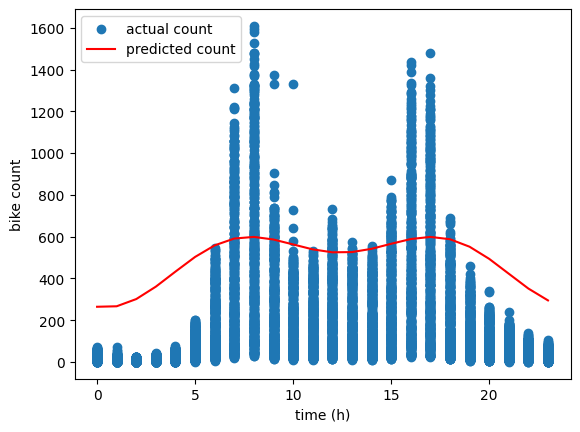

In [132]:
time_eval = np.arange(0, 24, 1)

plt.scatter(df_training["datetime"].dt.hour, df_training["bike_count"], label="actual count")
plt.plot(time_eval, predict_count_3(time_eval, 25, False, False), label="predicted count", color = "red")
plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()

#### Applying Ridge Regression

In [138]:
regr = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000, 5000, 10000], cv=5)
regr.fit(X, y)

print(f"Best alpha: {regr.alpha_}")
print(f"R2: {regr.score(X, y)}")

Best alpha: 5000.0
R2: 0.4282504347002295
